In [1]:
import subprocess, sys

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "opencv-python",
    "scikit-learn",
    "tensorflow",
    "h5py",
    "tables",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])
print("Dependencias instaladas correctamente.")

Dependencias instaladas correctamente.


# Librerias y dependencias

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Recall, Precision

# Carga de datos

In [3]:
train_data_path = 'train_data.h5'
test_data_path = 'test_data.h5'

train_data = pd.read_hdf(train_data_path)
test_data = pd.read_hdf(test_data_path)
train_data.head()

,ID,Patient Age,Patient Sex,target,filename,diagnostic,binary_target
6306,4584,42,Male,1,4584_left.jpg,D,0
2244,3126,41,Male,0,3126_right.jpg,N,1
1716,2553,54,Female,0,2553_right.jpg,N,1
6368,4653,68,Male,1,4653_left.jpg,D,0
4970,2618,58,Male,0,2618_left.jpg,N,1


Se separan los datos del objetivo

In [4]:
X_train, y_train = train_data.drop(columns=['target']), train_data['target']
X_test, y_test = test_data.drop(columns=['target']), test_data['target']
print(y_train.value_counts())

target
0    2298
1    1286
7     566
3     234
2     227
4     213
6     186
5     103
Name: count, dtype: int64


Se cargan las imagenes y se confirma que estas se puedan abrir

In [5]:
# Ruta a la carpeta de imagenes (relativa al notebook)
IMAGE_FOLDER_PATH = '../preprocessed_images'
IMAGE_SIZE = (128, 128)  # reducido para caber en RAM (~0.9 GB en lugar de ~3.8 GB a 224x224)

def load_images(filenames):
    images = []
    for filename in filenames:
        img_path = os.path.join(IMAGE_FOLDER_PATH, filename)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, IMAGE_SIZE)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype("float32")  # EfficientNetB0 incluye su propia normalizacion interna
            images.append(img)
        else:
            print(f"Warning: La imagen {filename} no se pudo cargar.")
    return np.array(images)

X_train_images = load_images(X_train['filename'])

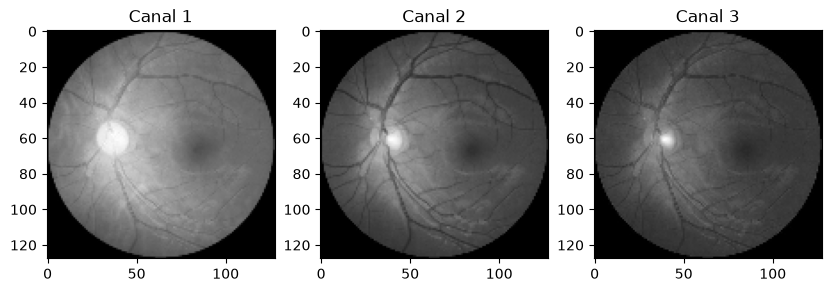

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].imshow(X_train_images[0][:,:,0], cmap="gray")
axs[0].set_title('Canal 1')
axs[1].imshow(X_train_images[0][:,:,1], cmap="gray")
axs[1].set_title('Canal 2')
axs[2].imshow(X_train_images[0][:,:,2], cmap="gray")
axs[2].set_title('Canal 3')
plt.show()

# Preparacion del Modelo

definicion del modelo

In [7]:
def build_transfer_model(input_shape=(128, 128, 3), num_classes=8):
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # base congelada: solo se entrena la cabeza densa

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu',
                               kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

input_shape = (128, 128, 3)
model = build_transfer_model(input_shape)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,563 (16.71 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Se reinicia el indice de y_train

In [8]:
y_train = y_train.reset_index(drop=True)
print(y_train.head())

0    1
1    0
2    0
3    1
4    0
Name: target, dtype: int64


se aumentan las imagenes de las categorias menos representadas a traves de copias modificadas de las originales

In [ ]:
def augment_images(images, labels):
    augmented_images = []
    augmented_labels = []

    for img, label in zip(images, labels):
        # Todas las clases minoritarias (2-7) reciben 3 copias aumentadas
        if label not in [0, 1]:
            h_flip_img = tf.image.flip_left_right(img)
            v_flip_img = tf.image.flip_up_down(img)

            h_flip_sat = tf.image.random_saturation(h_flip_img, lower=0.6, upper=1.4)
            augmented_images.append(h_flip_sat)
            augmented_labels.append(label)

            v_flip_sat = tf.image.random_saturation(v_flip_img, lower=0.6, upper=1.4)
            augmented_images.append(v_flip_sat)
            augmented_labels.append(label)

            hv_flip = tf.image.flip_left_right(tf.image.flip_up_down(img))
            augmented_images.append(hv_flip)
            augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_labels)

X_train_augmented, y_train_augmented = augment_images(X_train_images, y_train)

Ejemplo de imagenes generadas

In [ ]:
num_images_to_plot = 5
fig, axes = plt.subplots(1, num_images_to_plot, figsize=(20, 4))
for i in range(num_images_to_plot):
    idx = np.random.randint(0, len(X_train_augmented))
    axes[i].imshow(X_train_augmented[idx].astype(np.uint8))
    axes[i].set_title(f"Augmented {idx}")
    axes[i].axis("off")
plt.show()

print(f"Augmented: {X_train_augmented.shape[0]}  |  Original: {X_train_images.shape[0]}")

Se extrae un set de validacion del set de entrenamiento

In [11]:
validation_indices = []
for cls in sorted(y_train.unique()):
    cls_indices = y_train[y_train == cls].index
    n_val = max(1, int(len(cls_indices) * 0.2))
    chosen = np.random.choice(cls_indices, n_val, replace=False)
    validation_indices.extend(chosen)

validation_indices = np.array(validation_indices)

X_val = X_train_images[validation_indices]
y_val = y_train[validation_indices]

X_train_images = np.delete(X_train_images, validation_indices, axis=0)
y_train = y_train.drop(validation_indices).reset_index(drop=True)

print(f"Validation set: {X_val.shape[0]}  |  Training set: {X_train_images.shape[0]}")
print("Clases en validación:", dict(pd.Series(y_val.values).value_counts().sort_index()))

Validation set: 1019  |  Training set: 4094
Clases en validación: {0: np.int64(459), 1: np.int64(257), 2: np.int64(45), 3: np.int64(46), 4: np.int64(42), 5: np.int64(20), 6: np.int64(37), 7: np.int64(113)}


Se revisa la distribucion de la base de datos para entrenamiento

In [12]:
print("Class distribution in y_train:")
print(y_train.value_counts())

unique, counts = np.unique(y_train_augmented, return_counts=True)
print("\nClass distribution in y_train_augmented:")
print(dict(zip(unique, counts)))

Class distribution in y_train:
target
0    1839
1    1029
7     453
3     188
2     182
4     171
6     149
5      83
Name: count, dtype: int64

Class distribution in y_train_augmented:
{np.int64(2): np.int64(681), np.int64(3): np.int64(702), np.int64(4): np.int64(639), np.int64(5): np.int64(309), np.int64(6): np.int64(558), np.int64(7): np.int64(566)}


Se combinan los datos originales con los generados

In [13]:
X_train_combined = np.concatenate((X_train_images, X_train_augmented), axis=0)
y_train_combined = np.concatenate((y_train, y_train_augmented), axis=0)
# No se hace shuffle aqui - Keras lo hace internamente en model.fit (shuffle=True por defecto)
print(f"Total training samples: {X_train_combined.shape[0]}")

Total training samples: 7549


# Entrenamiento del modelo

In [ ]:
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_combined),
    y=y_train_combined
)
class_weights_dict = dict(enumerate(class_weights_array))
print("Class weights:", {k: round(v, 2) for k, v in class_weights_dict.items()})

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_combined,
    y_train_combined,
    epochs=120,
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

# Resultados del Modelo

se cargan las imagenes del set de prueba

In [22]:
X_test_images = load_images(X_test['filename'])

se corre el modelo con los datos de prueba y se grafica el resultado en una matriz de confusion

40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 311ms/step


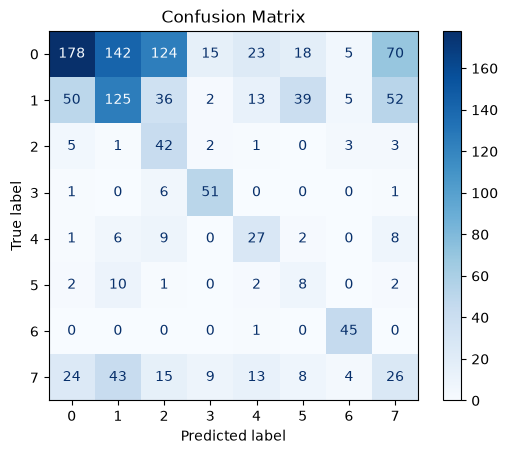

In [23]:
y_pred = model.predict(X_test_images)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

Se evalua la precision del modelo

In [21]:
from sklearn.metrics import accuracy_score, log_loss

accuracy = accuracy_score(y_test, y_pred_classes)
loss = log_loss(y_test, y_pred)
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

Loss: 1.4479
Accuracy: 0.3925


Se selecciona una imagen al azar para observar los filtros de activacion

In [24]:
image_index = np.random.randint(0, len(X_test_images))
image = X_test_images[image_index]
true_class = y_test.iloc[image_index]
predicted_class = y_pred_classes[image_index]

layer_outputs = [layer.output for layer in model.layers if "conv" in layer.name]
activation_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)
activations = activation_model.predict(np.expand_dims(image, axis=0))

plt.figure(figsize=(15, 15))
plt.subplot(1, len(activations) + 1, 1)
plt.imshow(image)
plt.title(f"Original\nTrue: {true_class}, Pred: {predicted_class}")
plt.axis("off")

for i, activation in enumerate(activations):
    num_filters = activation.shape[-1]
    size = activation.shape[1]
    display_grid = np.zeros((size, size * num_filters))
    for j in range(num_filters):
        x = activation[0, :, :, j]
        x -= x.mean()
        if x.std() != 0:
            x /= x.std()
        x *= 64
        x += 128
        x = np.clip(x, 0, 255).astype("uint8")
        display_grid[:, j * size:(j + 1) * size] = x
    scale = 20. / num_filters
    plt.figure(figsize=(scale * num_filters, scale))
    plt.title(f"Layer {i + 1}")
    plt.grid(False)
    plt.imshow(display_grid, aspect="auto", cmap="viridis")
plt.show()

ValueError: `outputs` argument cannot be empty. Received:
inputs=<KerasTensor shape=(None, 128, 128, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_238>
outputs=[]

Se revisa la precision del modelo por categoria

In [26]:
from sklearn.metrics import classification_report

classes = ['Normal', 'Diabetic Retinopathy', 'Glaucoma', 'Cataract',
           'Age-related Macular Degeneration', 'Hypertension', 'Myopia', 'Other']

report = classification_report(y_test, y_pred_classes, target_names=classes)
print(report)

                                  precision    recall  f1-score   support

                          Normal       0.68      0.31      0.43       575
            Diabetic Retinopathy       0.38      0.39      0.39       322
                        Glaucoma       0.18      0.74      0.29        57
                        Cataract       0.65      0.86      0.74        59
Age-related Macular Degeneration       0.34      0.51      0.41        53
                    Hypertension       0.11      0.32      0.16        25
                          Myopia       0.73      0.98      0.83        46
                           Other       0.16      0.18      0.17       142

                        accuracy                           0.39      1279
                       macro avg       0.40      0.54      0.43      1279
                    weighted avg       0.50      0.39      0.40      1279



In [ ]:
model.save('dl_model.h5')
print("Modelo guardado en dl_model.h5")

Modelo guardado en dl_model.h5
